# Feels Like Temperature 验证

读取官方测试数据，运行修改后的算法，并与 KGO 和原算法输出进行比较。

预处理采用投影坐标维名重命名，写出 `cli_input/` 供 CLI；结果写入 `cli_output/`；KGO / 原算法结果直接读官方投影 nc。

## 环境准备

In [1]:
%matplotlib inline

import sys
import warnings
import numpy as np
import xarray as xr
from pathlib import Path
import matplotlib.pyplot as plt

# 设置警告过滤器
warnings.filterwarnings("ignore", category=FutureWarning, module="xarray")
warnings.filterwarnings("ignore", category=UserWarning, message="pkg_resources is deprecated")

# 添加模块路径
PACKAGE_ROOT = Path.cwd().resolve().parents[0]
PROJECT_ROOT = PACKAGE_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from feels_like_temperature.src.feels_like_temperature import calculate_feels_like_temperature

## 数据预处理

将官方投影坐标样例映射为 meteva_base 六维输入（`member, level, time, dtime, lat, lon`）。

流程：读原数据 → 内存预处理 → 写出 `cli_input/`（供 CLI）；算法验证使用内存数据。

### 1. 预处理工具

In [2]:
import json

from feels_like_temperature.utils.utils import rebuild_to_meb_griddata

DATA_DIR = (PACKAGE_ROOT / "test_data/feels_like_temp_data").resolve()
CLI_INPUT_DIR = DATA_DIR / "cli_input"
CLI_OUTPUT_DIR = DATA_DIR / "cli_output"


def load_primary_dataarray(nc_path: Path, var_name: str) -> xr.DataArray:
    """读取 netCDF 主变量，并写入 grid_mapping_attrs。"""
    ds = xr.open_dataset(nc_path, decode_timedelta=False)
    try:
        if var_name not in ds.data_vars:
            raise ValueError(f"变量 {var_name} 不存在: {nc_path}")
        data = ds[var_name].load()
        grid_mapping_name = data.attrs.get("grid_mapping")
        if isinstance(grid_mapping_name, str) and grid_mapping_name in ds.variables:
            mapping_attrs_raw = dict(ds[grid_mapping_name].attrs)
            mapping_attrs_json_ready = {}
            for key, value in mapping_attrs_raw.items():
                if isinstance(value, np.ndarray):
                    mapping_attrs_json_ready[key] = value.tolist()
                elif isinstance(value, np.generic):
                    mapping_attrs_json_ready[key] = value.item()
                else:
                    mapping_attrs_json_ready[key] = value
            data.attrs["grid_mapping_attrs"] = json.dumps(
                mapping_attrs_json_ready, ensure_ascii=False
            )
        return data
    finally:
        ds.close()


def _extract_projected_spatial_2d(da: xr.DataArray) -> xr.DataArray:
    """提取二维空间场，并将投影维名统一映射为 lat/lon。"""
    arr = da
    for dim in list(arr.dims):
        if dim not in ("projection_y_coordinate", "projection_x_coordinate", "lat", "lon"):
            arr = arr.isel({dim: 0}, drop=True)
    rename_map = {}
    if "projection_y_coordinate" in arr.dims:
        rename_map["projection_y_coordinate"] = "lat"
    if "projection_x_coordinate" in arr.dims:
        rename_map["projection_x_coordinate"] = "lon"
    if rename_map:
        arr = arr.rename(rename_map)
    if arr.dims != ("lat", "lon"):
        arr = arr.transpose("lat", "lon")
    return arr


def _build_meb6d_from_spatial_2d(
    spatial: xr.DataArray,
    *,
    name: str,
    model: str,
    extra_attrs: dict | None = None,
) -> xr.DataArray:
    """由二维 lat/lon 场构造六维 meb 网格；通用默认属性由 rebuild_to_meb_griddata 补齐。"""
    units = str(spatial.attrs.get("units", "1"))
    values = spatial.values[np.newaxis, np.newaxis, np.newaxis, np.newaxis, :, :].astype(np.float32)
    attrs = {"units": units, "model": model}
    if extra_attrs:
        attrs.update(extra_attrs)
    grid_mapping_attrs = spatial.attrs.get("grid_mapping_attrs")
    if isinstance(grid_mapping_attrs, str) and grid_mapping_attrs.strip():
        attrs["grid_mapping_attrs"] = grid_mapping_attrs
    template = xr.DataArray(
        values,
        dims=("member", "level", "time", "dtime", "lat", "lon"),
        coords={
            "member": np.array(["data0"], dtype=object),
            "level": np.array([0.0], dtype=np.float32),
            "time": np.array([np.datetime64("1970-01-01T00:00:00")], dtype="datetime64[ns]"),
            "dtime": np.array([0], dtype=np.int32),
            "lat": spatial.coords["lat"].copy(deep=True),
            "lon": spatial.coords["lon"].copy(deep=True),
        },
        attrs=attrs,
        name=name,
    )
    return rebuild_to_meb_griddata(values, template, name=name, units=units)


def build_meb6d_from_projected(nc_path: Path, *, var_name: str) -> xr.DataArray:
    """由投影样例构造六维输入（仅维名重命名）。"""
    spatial = _extract_projected_spatial_2d(load_primary_dataarray(nc_path, var_name))
    return _build_meb6d_from_spatial_2d(
        spatial,
        name=var_name,
        model="official_test_preprocessed_rename",
    )


def save_meb6d_to_nc(data: xr.DataArray, dst_path: Path) -> None:
    """将内存中的六维 meb 数据写出为 nc（供 CLI 读取）。"""
    normalized = data.copy(deep=True)
    normalized.attrs = {k: ("" if v is None else v) for k, v in dict(normalized.attrs).items()}
    dst_path.parent.mkdir(parents=True, exist_ok=True)
    normalized.to_dataset(name=normalized.name).to_netcdf(dst_path)


def to_2d_values(data: xr.DataArray) -> np.ndarray:
    """将 DataArray 统一提取为二维 numpy 数组（lat, lon）。"""
    arr = data
    if {"projection_y_coordinate", "projection_x_coordinate"}.issubset(set(arr.dims)):
        arr = _extract_projected_spatial_2d(arr)
    else:
        for dim in list(arr.dims):
            if dim not in ("lat", "lon"):
                arr = arr.isel({dim: 0}, drop=True)
        if arr.dims != ("lat", "lon"):
            arr = arr.transpose("lat", "lon")
    return np.asarray(arr.values, dtype=np.float64)


def compare_stats(current: xr.DataArray, reference: xr.DataArray, tag: str):
    """对比两个二维场，计算平均绝对误差、最大绝对误差和均方根误差。"""
    c = to_2d_values(current)
    r = to_2d_values(reference)
    if c.shape != r.shape:
        raise ValueError(f"二维场形状不一致: current={c.shape}, reference={r.shape}")
    diff = c - r
    print(
        f"[{tag}] mean_abs={np.mean(np.abs(diff)):.8f}, "
        f"max_abs={np.max(np.abs(diff)):.8f}, rmse={np.sqrt(np.mean(diff**2)):.8f}"
    )
    return c, r, diff

### 2. 执行预处理

In [3]:
# 读原数据 → 内存预处理 → 写出 cli_input（供 CLI）；算法验证使用内存数据
paths = {
    "temperature": DATA_DIR / "20181121T1200Z-PT0012H00M-temperature_at_screen_level.nc",
    "wind_speed": DATA_DIR / "20181121T1200Z-PT0012H00M-wind_speed_at_10m.nc",
    "relative_humidity": DATA_DIR / "20181121T1200Z-PT0012H00M-relative_humidity_at_screen_level.nc",
    "pressure": DATA_DIR / "20181121T1200Z-PT0012H00M-pressure_at_mean_sea_level.nc",
    "expected": DATA_DIR / "kgo.nc",
    "original": DATA_DIR / "original_feels_like_temp_result.nc",
    "original_cli": DATA_DIR / "original_cli_result.nc",
}

temperature_meb = build_meb6d_from_projected(paths["temperature"], var_name="air_temperature")
wind_speed_meb = build_meb6d_from_projected(paths["wind_speed"], var_name="wind_speed")
relative_humidity_meb = build_meb6d_from_projected(
    paths["relative_humidity"], var_name="relative_humidity"
)
pressure_meb = build_meb6d_from_projected(
    paths["pressure"], var_name="air_pressure_at_sea_level"
)

input_outputs = [
    (paths["temperature"].name, temperature_meb),
    (paths["wind_speed"].name, wind_speed_meb),
    (paths["relative_humidity"].name, relative_humidity_meb),
    (paths["pressure"].name, pressure_meb),
]
for filename, data in input_outputs:
    save_meb6d_to_nc(data, CLI_INPUT_DIR / filename)
    print(f"写出: {CLI_INPUT_DIR / filename}")

print("算法输入:", temperature_meb.dims, temperature_meb.shape)


写出: D:\workspace\improver\feels_like_temperature\test_data\feels_like_temp_data\cli_input\20181121T1200Z-PT0012H00M-temperature_at_screen_level.nc
写出: D:\workspace\improver\feels_like_temperature\test_data\feels_like_temp_data\cli_input\20181121T1200Z-PT0012H00M-wind_speed_at_10m.nc
写出: D:\workspace\improver\feels_like_temperature\test_data\feels_like_temp_data\cli_input\20181121T1200Z-PT0012H00M-relative_humidity_at_screen_level.nc
写出: D:\workspace\improver\feels_like_temperature\test_data\feels_like_temp_data\cli_input\20181121T1200Z-PT0012H00M-pressure_at_mean_sea_level.nc
算法输入: ('member', 'level', 'time', 'dtime', 'lat', 'lon') (1, 1, 1, 1, 49, 53)


## 加载数据

In [4]:
# 算法输入（内存预处理结果）
t = temperature_meb
w = wind_speed_meb
rh = relative_humidity_meb
p = pressure_meb

# KGO / 原算法 / 原 CLI 读官方投影 nc（不预处理）
expected = load_primary_dataarray(paths["expected"], "feels_like_temperature")
original = load_primary_dataarray(paths["original"], "feels_like_temperature")
original_cli = load_primary_dataarray(paths["original_cli"], "feels_like_temperature")


## 调用calculate_feels_like_temperature函数计算体感温度

In [5]:
#计算体感温度
modified = calculate_feels_like_temperature(t, w, rh, p)

In [6]:
# 输入场二维数组（供输入数据图）
aux_data = {
    "Temperature": to_2d_values(t),
    "Wind Speed": to_2d_values(w),
    "Relative Humidity": to_2d_values(rh),
    "Pressure": to_2d_values(p),
}


## 输入数据图

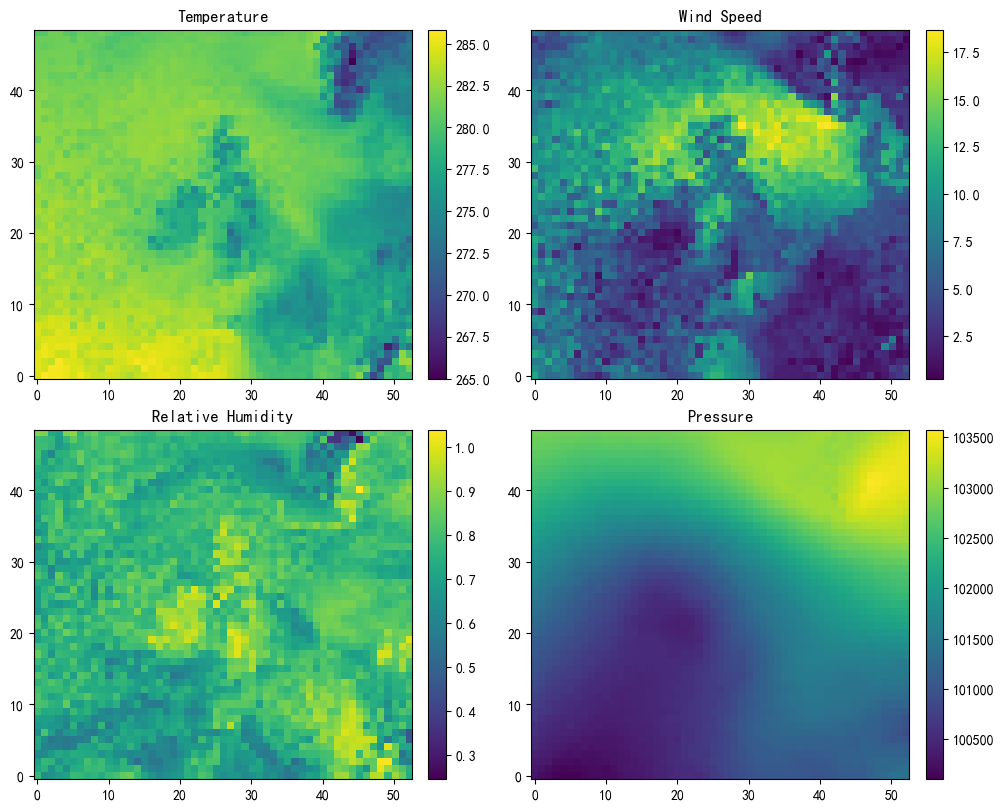

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)
for ax, (title, data) in zip(axes.ravel(), aux_data.items()):
    im = ax.imshow(data, origin="lower", cmap="viridis")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

## 结果对比图

[修改后算法-KGO] mean_abs=0.00000824, max_abs=0.00021362, rmse=0.00002940
[修改后算法-原算法] mean_abs=0.00000824, max_abs=0.00021362, rmse=0.00002940
[原算法-KGO] mean_abs=0.00000000, max_abs=0.00000000, rmse=0.00000000


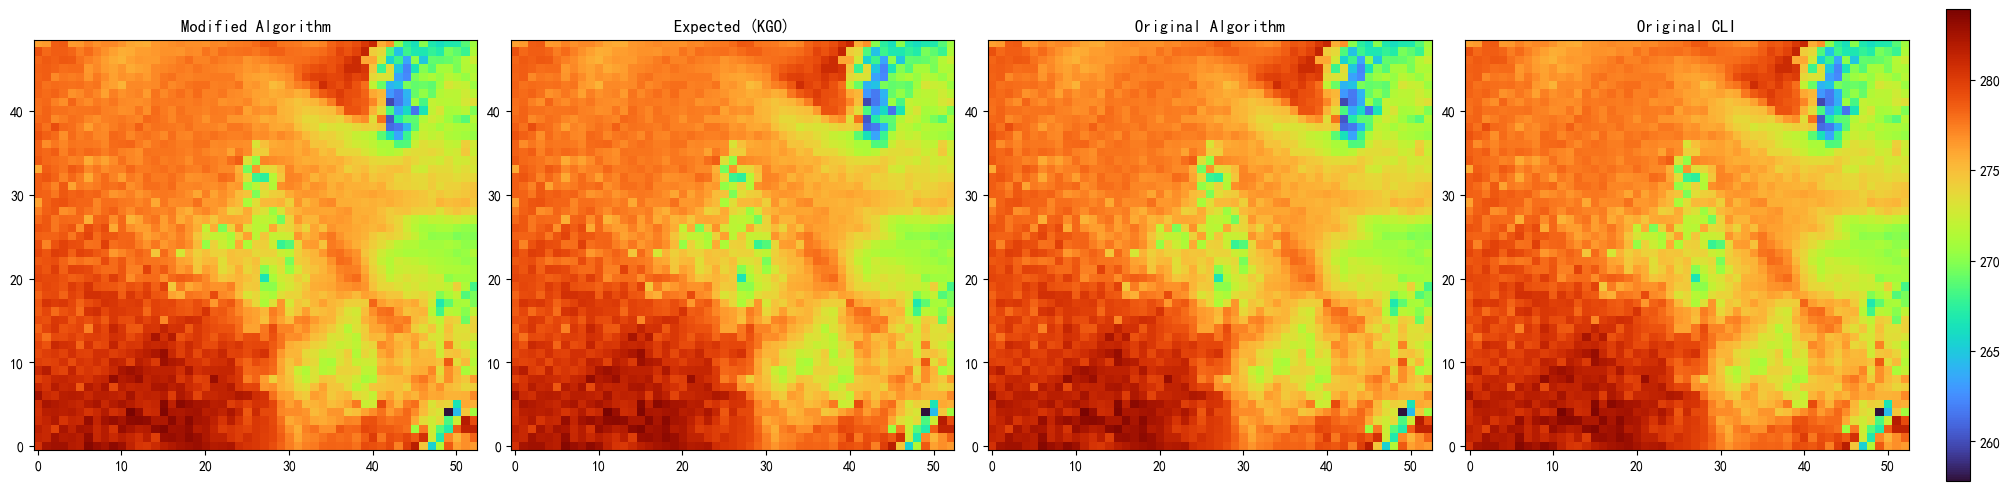

In [8]:
modified_2d, expected_2d, _ = compare_stats(modified, expected, "修改后算法-KGO")
_, original_2d, _ = compare_stats(modified, original, "修改后算法-原算法")
_, _, _ = compare_stats(original, expected, "原算法-KGO")

original_cli_2d = to_2d_values(original_cli)

vmin = np.nanmin([modified_2d, expected_2d, original_2d, original_cli_2d])
vmax = np.nanmax([modified_2d, expected_2d, original_2d, original_cli_2d])

fig, axes = plt.subplots(1, 4, figsize=(20, 4.8), constrained_layout=True)

im0 = axes[0].imshow(modified_2d, origin="lower", cmap="turbo", vmin=vmin, vmax=vmax)
axes[0].set_title("Modified Algorithm")

im1 = axes[1].imshow(expected_2d, origin="lower", cmap="turbo", vmin=vmin, vmax=vmax)
axes[1].set_title("Expected (KGO)")

im2 = axes[2].imshow(original_2d, origin="lower", cmap="turbo", vmin=vmin, vmax=vmax)
axes[2].set_title("Original Algorithm")

im3 = axes[3].imshow(original_cli_2d, origin="lower", cmap="turbo", vmin=vmin, vmax=vmax)
axes[3].set_title("Original CLI")

fig.colorbar(im3, ax=axes, fraction=0.025, pad=0.02)
plt.show()


## CLI 应用示例与结果对比

CLI 从 `cli_input/` 读取预处理输入；下方直接调用 `der_feel_like_temp.process`，并与原 CLI、KGO 对比。

[修改后算法CLI-原算法CLI] mean_abs=0.00000824, max_abs=0.00021362, rmse=0.00002940
[修改后算法CLI-KGO] mean_abs=0.00000824, max_abs=0.00021362, rmse=0.00002940
[原算法CLI-KGO] mean_abs=0.00000000, max_abs=0.00000000, rmse=0.00000000


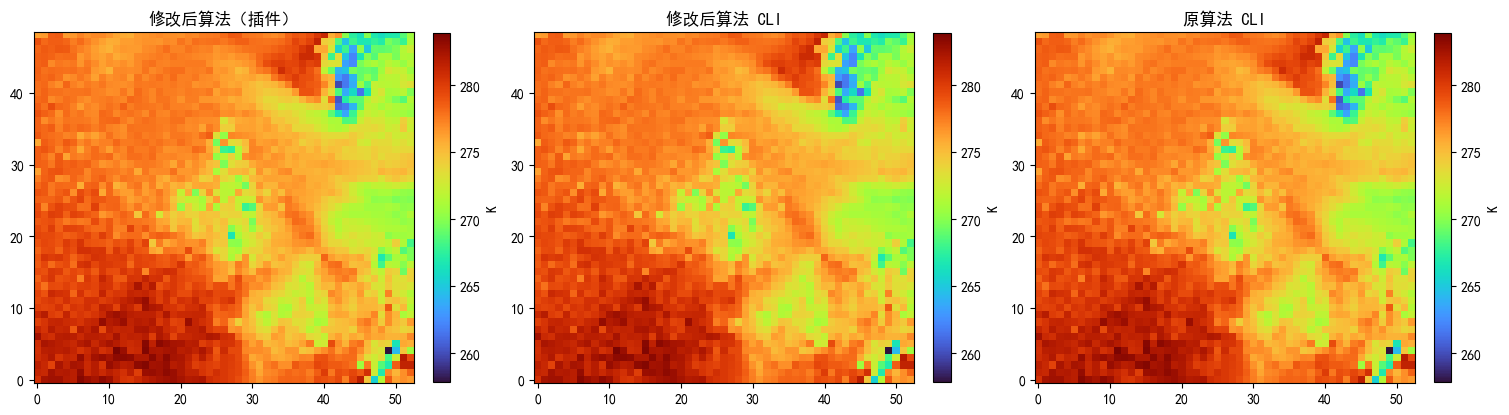

In [9]:
from feels_like_temperature.cli.der_feel_like_temp import process as cli_flt_process

cli_result = cli_flt_process(
    str(CLI_INPUT_DIR / paths["temperature"].name),
    str(CLI_INPUT_DIR / paths["wind_speed"].name),
    str(CLI_INPUT_DIR / paths["relative_humidity"].name),
    str(CLI_INPUT_DIR / paths["pressure"].name),
    output_path=None,
)

cli_2d, _, _ = compare_stats(cli_result, original_cli, "修改后算法CLI-原算法CLI")
_, _, _ = compare_stats(cli_result, expected, "修改后算法CLI-KGO")
_, _, _ = compare_stats(original_cli, expected, "原算法CLI-KGO")

vmin_cli = np.nanmin([modified_2d, cli_2d, original_cli_2d])
vmax_cli = np.nanmax([modified_2d, cli_2d, original_cli_2d])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), constrained_layout=True)
for ax, arr, title in zip(
    axes,
    [modified_2d, cli_2d, original_cli_2d],
    ["修改后算法（插件）", "修改后算法 CLI", "原算法 CLI"],
):
    im = ax.imshow(arr, origin="lower", cmap="turbo", vmin=vmin_cli, vmax=vmax_cli)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, label="K")
plt.show()
